# Real-World Online Retail Data Analysis

## Module 2 — Data Analysis with Python

### Dataset
UCI Online Retail II Dataset

### Tools Used
- Python
- NumPy
- Pandas
- Matplotlib

### Objective
To explore, clean, analyze, and visualize real-world online
retail transaction data using Python.

In [106]:

# IMPORTING REQUIRED LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)
print("All libraries imported successfully!")

All libraries imported successfully!


In [107]:

# LOADING THE FIRST YEAR OF DATA

# Reading the 2009-2010 sheet from the Excel file
df_2009_2010 = pd.read_excel("online_retail_II.xlsx",sheet_name="Year 2009-2010")

# Display the number of rows and columns
print("2009-2010 dataset shape:", df_2009_2010.shape)

2009-2010 dataset shape: (525461, 8)


In [108]:

# LOADING THE SECOND YEAR OF DATA

# Reading the 2010-2011 sheet
df_2010_2011 = pd.read_excel("online_retail_II.xlsx",sheet_name="Year 2010-2011")

# Display the number of rows and columns
print("2010-2011 dataset shape:", df_2010_2011.shape)

2010-2011 dataset shape: (536642, 8)


In [109]:

# COMBINING BOTH YEARS

# Combining the two yearly datasets into one DataFrame
df = pd.concat([df_2009_2010, df_2010_2011],ignore_index=True)

# Display the final combined dataset size
print("Combined dataset shape:", df.shape)

Combined dataset shape: (1062103, 8)


In [110]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [111]:
df.tail(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1062093,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France
1062094,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France
1062095,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
1062096,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
1062097,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1062098,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1062099,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1062100,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1062101,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1062102,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [112]:
# Getting the number of rows and columns
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 1062103
Number of columns: 8


In [113]:
# Printing all column names in the dataset. so we know exactly what information is available.

print("Columns in the dataset:\n")

for column in df.columns:
    print("-", column)

Columns in the dataset:

- Invoice
- StockCode
- Description
- Quantity
- InvoiceDate
- Price
- Customer ID
- Country


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062103 entries, 0 to 1062102
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1062103 non-null  object        
 1   StockCode    1062103 non-null  object        
 2   Description  1057721 non-null  object        
 3   Quantity     1062103 non-null  int64         
 4   InvoiceDate  1062103 non-null  datetime64[ns]
 5   Price        1062103 non-null  float64       
 6   Customer ID  819139 non-null   float64       
 7   Country      1062103 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 64.8+ MB


In [115]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.062103e+06,1062103,1.062103e+06,819139.000000
mean,9.975063e+00,2011-01-01 21:08:45.621733376,4.660462e+00,15321.672803
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-08 09:15:00,1.250000e+00,13969.000000
50%,3.000000e+00,2010-12-07 10:14:00,2.100000e+00,15251.000000
75%,1.000000e+01,2011-07-21 11:21:00,4.150000e+00,16795.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.731215e+02,NaN,1.238589e+02,1697.632574


In [116]:
print("Data types of each column:")

print(df.dtypes)

Data types of each column:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [117]:
print("Number of unique values in each column:\n")

for column in df.columns:
    print(f"{column}:{df[column].nunique():,} unique values")

Number of unique values in each column:

Invoice:53,628 unique values
StockCode:5,306 unique values
Description:5,698 unique values
Quantity:1,057 unique values
InvoiceDate:47,635 unique values
Price:2,807 unique values
Customer ID:5,942 unique values
Country:43 unique values


In [118]:
missing_values = df.isnull().sum()

print("Missing values in each column:\n")

print(missing_values)

Missing values in each column:

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    242964
Country             0
dtype: int64


In [119]:
#  MISSING VALUE PERCENTAGE
missing_percentage = ((df.isnull().sum()) / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table = missing_table.sort_values(by="Missing Percentage",ascending=False)

display(missing_table)

,Missing Count,Missing Percentage
Customer ID,242964,22.875747
Description,4382,0.412578
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


In [120]:
# CHECKING FOR THE DUPLICATE ROWS FROM THE DATASET
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 29066


In [121]:
# VIEW DUPLICATE ROWS

# keep=False, marks every occurrence of a duplicate
# so we can inspect all duplicate records.

duplicates = df[df.duplicated(keep=False)]

print("Number of rows involved in duplicates:",len(duplicates))

# Display the first 20 duplicate records

display(duplicates.head(10))

Number of rows involved in duplicates: 57389


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [122]:

# CELL 18: IDENTIFYING CANCELLED TRANSACTIONS

df["Invoice"] = df["Invoice"].astype(str)

# Selecting invoices beginning with "C".

cancelled_transactions = df[df["Invoice"].str.startswith("C")]

print("Cancelled transaction rows:",len(cancelled_transactions))

# Displaying a few cancelled transactions

display(cancelled_transactions.head(10))

Cancelled transaction rows: 19457


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [123]:
#CANCELLATION PERCENTAGE

# Calculating the percentage of transaction rows, that represent cancellations.

cancellation_percentage = (len(cancelled_transactions) / len(df)) * 100

print(f"Cancellation percentage: "f"{cancellation_percentage:.2f}%")

Cancellation percentage: 1.83%


In [124]:
# ANALYZING QUANTITY

print("Quantity statistics:\n")

print("Minimum Quantity:", df["Quantity"].min())
print("Maximum Quantity:", df["Quantity"].max())
print("Average Quantity:", df["Quantity"].mean())
print("Median Quantity:", df["Quantity"].median())

Quantity statistics:

Minimum Quantity: -80995
Maximum Quantity: 80995
Average Quantity: 9.975062682244566
Median Quantity: 3.0


In [125]:
# CELL 21: CHECKING NEGATIVE QUANTITIES
negative_quantity = df[df["Quantity"] < 0]

print("Rows with negative quantity:",len(negative_quantity))

display(negative_quantity.head(10))

Rows with negative quantity: 22913


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [126]:
# CELL 23: CHECKING INVALID PRICES

invalid_prices = df[df["Price"] <= 0]

print( "Rows with zero or negative prices:",len(invalid_prices))

display(invalid_prices.head(10))

Rows with zero or negative prices: 6202


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [127]:
#CREATING CLEAN DATASET COPY
# We don't want to modify our original dataset (df).
# So we create a separate copy for data cleaning.

clean_df = df.copy()

print("Clean dataset created successfully!")
print("Original dataset rows:", len(df))
print("Cleaning dataset rows:", len(clean_df))

Clean dataset created successfully!
Original dataset rows: 1062103
Cleaning dataset rows: 1062103


In [128]:

# REMOVING CANCELLED TRANSACTIONS

# Counting rows before removing cancellations
before = len(clean_df)

# Removing invoices that start with "C"
clean_df = clean_df[~clean_df["Invoice"].str.startswith("C")]

# Counting rows after removing cancellations
after = len(clean_df)

print("Rows before removing cancellations:", before)
print("Rows after removing cancellations:", after)
print("Cancelled rows removed:", before - after)

Rows before removing cancellations: 1062103
Rows after removing cancellations: 1042646
Cancelled rows removed: 19457


In [129]:
# REMOVING INVALID QUANTITIES

# Counting rows before cleaning
before = len(clean_df)

# Keeping only transactions where quantity is greater than zero
clean_df = clean_df[clean_df["Quantity"] > 0]

# Counting rows after cleaning
after = len(clean_df)

print("Rows before quantity cleaning:", before)
print("Rows after quantity cleaning:", after)
print("Invalid quantity rows removed:", before - after)

Rows before quantity cleaning: 1042646
Rows after quantity cleaning: 1039189
Invalid quantity rows removed: 3457


In [130]:

# REMOVING INVALID PRICES
# Counting rows before cleaning
before = len(clean_df)

# Keeping only transactions with a positive price
clean_df = clean_df[clean_df["Price"] > 0]

# Count rows after cleaning
after = len(clean_df)

print("Rows before price cleaning:", before)
print("Rows after price cleaning:", after)
print("Invalid price rows removed:", before - after)

Rows before price cleaning: 1039189
Rows after price cleaning: 1036444
Invalid price rows removed: 2745


In [131]:
#CHECK MISSING DESCRIPTIONS

missing_description = clean_df["Description"].isnull().sum()

print("Missing product descriptions:", missing_description)

Missing product descriptions: 0


In [132]:

# HANDLE MISSING DESCRIPTIONS

# Replacing missing descriptions with a meaningful label
clean_df["Description"] = (
    clean_df["Description"].fillna("Unknown Product"))

# Check again
print("Missing descriptions after cleaning:",clean_df["Description"].isnull().sum())

Missing descriptions after cleaning: 0


In [133]:

# CHECKING MISSING CUSTOMER IDs
missing_customer_ids = clean_df["Customer ID"].isnull().sum()

missing_customer_percentage = (missing_customer_ids / len(clean_df)) * 100

print("Missing Customer IDs:",missing_customer_ids)

print(f"Missing Customer ID percentage: "f"{missing_customer_percentage:.2f}%")

Missing Customer IDs: 236087
Missing Customer ID percentage: 22.78%


In [134]:
# REMOVING DUPLICATES
# Counting rows before removing duplicates
before = len(clean_df)

# Remove completely duplicated rows
clean_df = clean_df.drop_duplicates()

# Count rows after removing duplicates
after = len(clean_df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicate rows removed:", before - after)

Rows before removing duplicates: 1036444
Rows after removing duplicates: 1007914
Duplicate rows removed: 28530


In [135]:

#CONVERTING INVOICE DATE

# Convert InvoiceDate to Pandas datetime format
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

# Check the data type
print("InvoiceDate data type:",clean_df["InvoiceDate"].dtype)

InvoiceDate data type: datetime64[ns]


In [136]:
# CREATE REVENUE COLUMN

# Calculate revenue for every transaction
clean_df["Revenue"] = (clean_df["Quantity"] * clean_df["Price"])

# Display important columns
display(clean_df[
        [
            "Invoice",
            "Quantity",
            "Price",
            "Revenue"
        ]
    ].head(10)
)

,Invoice,Quantity,Price,Revenue
0,489434,12,6.95,83.4
1,489434,12,6.75,81.0
2,489434,12,6.75,81.0
3,489434,48,2.10,100.8
4,489434,24,1.25,30.0
5,489434,24,1.65,39.6
6,489434,24,1.25,30.0
7,489434,10,5.95,59.5
8,489435,12,2.55,30.6
9,489435,12,3.75,45.0


In [137]:
#VERIFY REVENUE

print("Minimum Revenue:", clean_df["Revenue"].min())
print("Maximum Revenue:", clean_df["Revenue"].max())
print("Average Revenue:", clean_df["Revenue"].mean())

# Check for missing revenue values
print("Missing Revenue values:",clean_df["Revenue"].isnull().sum())

Minimum Revenue: 0.001
Maximum Revenue: 168469.6
Average Revenue: 20.315505537178765
Missing Revenue values: 0


In [138]:
#CREATE DATE FEATURES

# Extract year from InvoiceDate
clean_df["Year"] = (
    clean_df["InvoiceDate"].dt.year
)

# Extract month number
clean_df["Month"] = (
    clean_df["InvoiceDate"].dt.month
)

# Extract month name
clean_df["Month_Name"] = (
    clean_df["InvoiceDate"].dt.month_name()
)

# Extract day of week
clean_df["Day_Name"] = (
    clean_df["InvoiceDate"].dt.day_name()
)

# Extract hour
clean_df["Hour"] = (
    clean_df["InvoiceDate"].dt.hour
)

# Display the newly created columns
display(
    clean_df[
        [
            "InvoiceDate",
            "Year",
            "Month",
            "Month_Name",
            "Day_Name",
            "Hour"
        ]
    ].head(10)
)

,InvoiceDate,Year,Month,Month_Name,Day_Name,Hour
0,2009-12-01 07:45:00,2009,12,December,Tuesday,7
1,2009-12-01 07:45:00,2009,12,December,Tuesday,7
2,2009-12-01 07:45:00,2009,12,December,Tuesday,7
3,2009-12-01 07:45:00,2009,12,December,Tuesday,7
4,2009-12-01 07:45:00,2009,12,December,Tuesday,7
5,2009-12-01 07:45:00,2009,12,December,Tuesday,7
6,2009-12-01 07:45:00,2009,12,December,Tuesday,7
7,2009-12-01 07:45:00,2009,12,December,Tuesday,7
8,2009-12-01 07:46:00,2009,12,December,Tuesday,7
9,2009-12-01 07:46:00,2009,12,December,Tuesday,7


In [139]:
# ============================================
# DIAGNOSTIC CELL
# ============================================

print("RAW DATASET")
print("df shape:", df.shape)

print("\nCLEAN DATASET")
print("clean_df shape:", clean_df.shape)

print("\nCOLUMNS")
print(clean_df.columns.tolist())

print("\nFIRST 5 ROWS OF RAW DATA")
display(df.head())

print("\nFIRST 5 ROWS OF CLEAN DATA")
display(clean_df.head())


RAW DATASET
df shape: (1062103, 8)

CLEAN DATASET
clean_df shape: (1007914, 14)

COLUMNS
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Day_Name', 'Hour']

FIRST 5 ROWS OF RAW DATA


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



FIRST 5 ROWS OF CLEAN DATA


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Day_Name,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,Tuesday,7


In [140]:

#RESET CLEAN DATASET

# Start again from our original raw dataset.
# This removes the previous empty clean_df.

clean_df = df.copy()

print("Clean dataset reset successfully!")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

display(clean_df.head())

Clean dataset reset successfully!
Rows: 1062103
Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [141]:
# CHECK INVOICE VALUES

# Convert Invoice to text so we can safely
# identify cancelled transactions.
clean_df["Invoice"] = clean_df["Invoice"].astype(str)

# Display a few invoice values
print("Sample Invoice values:")
print(clean_df["Invoice"].head(10).tolist())

# Count cancelled transactions
# Cancelled invoices start with the letter "C"
cancelled_count = clean_df["Invoice"].str.startswith("C").sum()

print("\nCancelled transaction rows:", cancelled_count)

Sample Invoice values:
['489434', '489434', '489434', '489434', '489434', '489434', '489434', '489434', '489435', '489435']

Cancelled transaction rows: 19457


In [142]:

# REMOVE CANCELLED TRANSACTIONS


before = len(clean_df)

# Keep only invoices that are NOT cancelled
clean_df = clean_df[
    ~clean_df["Invoice"].str.startswith("C")
].copy()

after = len(clean_df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 1062103
Rows after: 1042646
Rows removed: 19457


In [143]:
# REMOVE CANCELLED TRANSACTIONS


# Store the number of rows before cleaning
before = len(clean_df)

# Cancelled invoices start with "C".
# The ~ symbol means NOT.
# Therefore, we keep only normal sales invoices.
clean_df = clean_df[
    ~clean_df["Invoice"].str.startswith("C")
].copy()

# Store the number of rows after cleaning
after = len(clean_df)

print("Rows before:", before)
print("Rows after:", after)
print("Cancelled rows removed:", before - after)

Rows before: 1042646
Rows after: 1042646
Cancelled rows removed: 0


In [144]:
# CHECK QUANTITY

# Check the range of quantities
print("Minimum Quantity:", clean_df["Quantity"].min())
print("Maximum Quantity:", clean_df["Quantity"].max())

# Count valid and invalid quantities
positive_quantity = (clean_df["Quantity"] > 0).sum()
invalid_quantity = (clean_df["Quantity"] <= 0).sum()

print("\nQuantity > 0:", positive_quantity)
print("Quantity <= 0:", invalid_quantity)

Minimum Quantity: -9600
Maximum Quantity: 80995

Quantity > 0: 1039189
Quantity <= 0: 3457


In [145]:
# REMOVE INVALID QUANTITIES

before = len(clean_df)

# For sales analysis, keep only positive quantities.
clean_df = clean_df[
    clean_df["Quantity"] > 0
].copy()

after = len(clean_df)

print("Rows before:", before)
print("Rows after:", after)
print("Invalid quantity rows removed:", before - after)

Rows before: 1042646
Rows after: 1039189
Invalid quantity rows removed: 3457


In [146]:
# CHECK PRICE

print("Minimum Price:", clean_df["Price"].min())
print("Maximum Price:", clean_df["Price"].max())

# Count valid and invalid prices
positive_price = (clean_df["Price"] > 0).sum()
invalid_price = (clean_df["Price"] <= 0).sum()

print("\nPrice > 0:", positive_price)
print("Price <= 0:", invalid_price)

Minimum Price: -53594.36
Maximum Price: 25111.09

Price > 0: 1036444
Price <= 0: 2745


In [147]:

# REMOVE INVALID PRICES

before = len(clean_df)

# Keep only transactions with a positive price.
clean_df = clean_df[
    clean_df["Price"] > 0
].copy()

after = len(clean_df)

print("Rows before:", before)
print("Rows after:", after)
print("Invalid price rows removed:", before - after)

Rows before: 1039189
Rows after: 1036444
Invalid price rows removed: 2745


In [148]:
# VERIFY CLEAN DATASET

print("Clean dataset shape:", clean_df.shape)

print("\nFirst 5 rows:")
display(clean_df.head())

print("\nMissing values:")
print(clean_df.isnull().sum())

Clean dataset shape: (1036444, 8)

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Missing values:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236087
Country             0
dtype: int64


In [149]:
# CREATE REVENUE

# Revenue = Quantity × Price

clean_df["Revenue"] = (
    clean_df["Quantity"] *
    clean_df["Price"]
)

print("Revenue column created successfully!")

display(
    clean_df[
        [
            "Invoice",
            "Quantity",
            "Price",
            "Revenue"
        ]
    ].head(10)
)

Revenue column created successfully!


,Invoice,Quantity,Price,Revenue
0,489434,12,6.95,83.4
1,489434,12,6.75,81.0
2,489434,12,6.75,81.0
3,489434,48,2.10,100.8
4,489434,24,1.25,30.0
5,489434,24,1.65,39.6
6,489434,24,1.25,30.0
7,489434,10,5.95,59.5
8,489435,12,2.55,30.6
9,489435,12,3.75,45.0


In [150]:
# VERIFY REVENUE

print("Minimum Revenue:", clean_df["Revenue"].min())
print("Maximum Revenue:", clean_df["Revenue"].max())
print("Average Revenue:", clean_df["Revenue"].mean())

print(
    "Missing Revenue values:",
    clean_df["Revenue"].isnull().sum()
)

Minimum Revenue: 0.001
Maximum Revenue: 168469.6
Average Revenue: 20.21143528063263
Missing Revenue values: 0


In [151]:
# CHECK MISSING VALUES

# Count missing values in every column
missing_values = clean_df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236087
Country             0
Revenue             0
dtype: int64


In [152]:
#  MISSING VALUE PERCENTAGE

# Calculate the percentage of missing values
# in each column.

missing_percentage = (
    clean_df.isnull().sum() / len(clean_df)
) * 100

# Create a table for easier understanding
missing_table = pd.DataFrame({
    "Missing Count": clean_df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

# Sort from highest to lowest
missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_table)

,Missing Count,Missing Percentage
Customer ID,236087,22.778558
Invoice,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
Description,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000
Revenue,0,0.000000


In [153]:
# HANDLE MISSING DESCRIPTIONS

# Count missing descriptions before cleaning
before_missing = clean_df["Description"].isnull().sum()

print("Missing descriptions before:", before_missing)

# Replace missing descriptions
clean_df["Description"] = clean_df["Description"].fillna(
    "Unknown Product"
)

# Check again
after_missing = clean_df["Description"].isnull().sum()

print("Missing descriptions after:", after_missing)

Missing descriptions before: 0
Missing descriptions after: 0


In [154]:
# ANALYZE CUSTOMER ID

# Count missing Customer IDs
missing_customer_ids = clean_df["Customer ID"].isnull().sum()

# Calculate percentage
customer_id_percentage = (
    missing_customer_ids / len(clean_df)
) * 100

print("Missing Customer IDs:", missing_customer_ids)

print(
    f"Missing Customer ID percentage: "
    f"{customer_id_percentage:.2f}%"
)

Missing Customer IDs: 236087
Missing Customer ID percentage: 22.78%


In [155]:

# CHECK DUPLICATES

# Count completely identical rows
duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 28530


In [156]:
# REMOVE DUPLICATES

before = len(clean_df)

# Remove completely duplicated rows
clean_df = clean_df.drop_duplicates().copy()

after = len(clean_df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicate rows removed:", before - after)

Rows before: 1036444
Rows after: 1007914
Duplicate rows removed: 28530


In [157]:
# CONVERT INVOICE DATE

# Convert InvoiceDate into Pandas datetime format
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"],
    errors="coerce"
)

# Check the data type
print("InvoiceDate data type:")
print(clean_df["InvoiceDate"].dtype)

# Count dates that could not be converted
print(
    "\nInvalid/missing dates:",
    clean_df["InvoiceDate"].isnull().sum()
)

InvoiceDate data type:
datetime64[ns]

Invalid/missing dates: 0


In [158]:
# EXTRACT YEAR

# Extract the year from InvoiceDate
clean_df["Year"] = clean_df["InvoiceDate"].dt.year

# Display year distribution
print("Transactions by year:")

print(
    clean_df["Year"].value_counts().sort_index()
)

Transactions by year:
Year
2009     43453
2010    480573
2011    483888
Name: count, dtype: int64


In [159]:
# EXTRACT MONTH

# Extract month number
clean_df["Month"] = clean_df["InvoiceDate"].dt.month

# Extract month name
clean_df["Month_Name"] = (
    clean_df["InvoiceDate"].dt.month_name()
)

display(
    clean_df[
        [
            "InvoiceDate",
            "Year",
            "Month",
            "Month_Name"
        ]
    ].head(10)
)

,InvoiceDate,Year,Month,Month_Name
0,2009-12-01 07:45:00,2009,12,December
1,2009-12-01 07:45:00,2009,12,December
2,2009-12-01 07:45:00,2009,12,December
3,2009-12-01 07:45:00,2009,12,December
4,2009-12-01 07:45:00,2009,12,December
5,2009-12-01 07:45:00,2009,12,December
6,2009-12-01 07:45:00,2009,12,December
7,2009-12-01 07:45:00,2009,12,December
8,2009-12-01 07:46:00,2009,12,December
9,2009-12-01 07:46:00,2009,12,December


In [160]:
# EXTRACT DAY OF WEEK

# Extract the day name
clean_df["Day_Name"] = (
    clean_df["InvoiceDate"].dt.day_name()
)

display(clean_df[[ "InvoiceDate","Day_Name"]].head(10))

,InvoiceDate,Day_Name
0,2009-12-01 07:45:00,Tuesday
1,2009-12-01 07:45:00,Tuesday
2,2009-12-01 07:45:00,Tuesday
3,2009-12-01 07:45:00,Tuesday
4,2009-12-01 07:45:00,Tuesday
5,2009-12-01 07:45:00,Tuesday
6,2009-12-01 07:45:00,Tuesday
7,2009-12-01 07:45:00,Tuesday
8,2009-12-01 07:46:00,Tuesday
9,2009-12-01 07:46:00,Tuesday


In [161]:

# EXTRACT TRANSACTION HOUR

# Extract the hour from InvoiceDate
clean_df["Hour"] = clean_df["InvoiceDate"].dt.hour

display(
    clean_df[
        [
            "InvoiceDate",
            "Hour"
        ]
    ].head(10)
)

,InvoiceDate,Hour
0,2009-12-01 07:45:00,7
1,2009-12-01 07:45:00,7
2,2009-12-01 07:45:00,7
3,2009-12-01 07:45:00,7
4,2009-12-01 07:45:00,7
5,2009-12-01 07:45:00,7
6,2009-12-01 07:45:00,7
7,2009-12-01 07:45:00,7
8,2009-12-01 07:46:00,7
9,2009-12-01 07:46:00,7


In [162]:
# FINAL CLEANING CHECK

print("========== FINAL DATASET ==========")

print("\nDataset Shape:")
print(clean_df.shape)

print("\nColumns:")
print(clean_df.columns.tolist())

print("\nMissing Values:")
print(clean_df.isnull().sum())

print("\nDuplicate Rows:")
print(clean_df.duplicated().sum())

print("\nFirst 5 Clean Records:")
display(clean_df.head())

========== FINAL DATASET ==========

Dataset Shape:
(1007914, 14)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Day_Name', 'Hour']

Missing Values:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    228488
Country             0
Revenue             0
Year                0
Month               0
Month_Name          0
Day_Name            0
Hour                0
dtype: int64

Duplicate Rows:
0

First 5 Clean Records:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Day_Name,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,Tuesday,7


In [163]:
# TOTAL REVENUE

# Calculate total revenue generated
# from all valid transactions.

total_revenue = clean_df["Revenue"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £20,476,282.45


In [164]:

# TOTAL QUANTITY SOLD

# Calculate the total number of products sold.

total_quantity = clean_df["Quantity"].sum()

print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 11,205,156


In [165]:
# TOTAL TRANSACTIONS

# Count unique invoices.
# Each invoice represents an order/transaction.

total_transactions = clean_df["Invoice"].nunique()

print(
    f"Total Transactions: {total_transactions:,}"
)

Total Transactions: 40,077


In [166]:
# UNIQUE PRODUCTS

# Count unique StockCode values.
# StockCode represents a product.

total_products = clean_df["StockCode"].nunique()

print(
    f"Total Unique Products: {total_products:,}"
)

Total Unique Products: 4,918


In [167]:
# UNIQUE CUSTOMERS

# Count unique customers while ignoring
# missing Customer IDs.

total_customers = clean_df["Customer ID"].nunique()

print(
    f"Total Unique Customers: {total_customers:,}"
)

Total Unique Customers: 5,878


In [168]:
# COUNTRIES

# Count the number of countries represented
# in the dataset.

total_countries = clean_df["Country"].nunique()

print(
    f"Total Countries: {total_countries}"
)

Total Countries: 43


In [169]:
# BUSINESS SUMMARY

business_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Transactions",
        "Unique Products",
        "Unique Customers",
        "Countries Served"
    ],

    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_quantity:,}",
        f"{total_transactions:,}",
        f"{total_products:,}",
        f"{total_customers:,}",
        f"{total_countries}"
    ]
})

display(business_summary)

,Metric,Value
0,Total Revenue,"£20,476,282.45"
1,Total Quantity Sold,"11,205,156"
2,Total Transactions,"40,077"
3,Unique Products,"4,918"
4,Unique Customers,"5,878"
5,Countries Served,43


In [170]:
# AVERAGE ORDER VALUE

# Calculate the average revenue generated
# per transaction.

average_order_value = (
    total_revenue / total_transactions
)

print(
    f"Average Order Value: "
    f"£{average_order_value:,.2f}"
)

Average Order Value: £510.92


In [171]:

# REVENUE PER PRODUCT

# Calculate average revenue generated
# per unique product.

average_revenue_per_product = (
    total_revenue / total_products
)

print(
    f"Average Revenue per Product: "
    f"£{average_revenue_per_product:,.2f}"
)

Average Revenue per Product: £4,163.54


In [172]:
# MONTHLY REVENUE

# Group transactions by year and month
# and calculate total revenue.

monthly_revenue = (
    clean_df
    .groupby(["Year", "Month", "Month_Name"])["Revenue"]
    .sum()
    .reset_index()
)

# Sort chronologically
monthly_revenue = monthly_revenue.sort_values(
    ["Year", "Month"]
)

display(monthly_revenue)

,Year,Month,Month_Name,Revenue
0,2009,12,December,822483.950
1,2010,1,January,651155.112
2,2010,2,February,551504.726
3,2010,3,March,830915.261
4,2010,4,April,678875.252
5,2010,5,May,657705.500
6,2010,6,June,749537.310
7,2010,7,July,648810.270
8,2010,8,August,695251.910
9,2010,9,September,921696.991


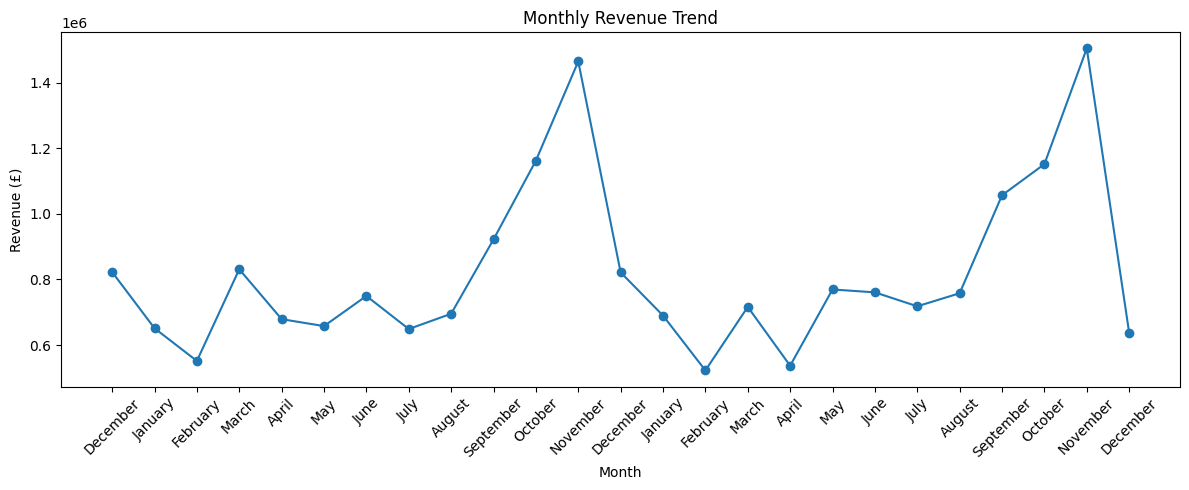

In [173]:
# MONTHLY REVENUE CHART

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(
    monthly_revenue.index,
    monthly_revenue["Month_Name"],
    rotation=45
)

plt.tight_layout()
plt.show()

In [174]:
# TOP 10 PRODUCTS BY REVENUE

top_products = (clean_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index())

display(top_products)

,Description,Revenue
0,Manual,339241.29
1,REGENCY CAKESTAND 3 TIER,330590.32
2,DOTCOM POSTAGE,309854.11
3,WHITE HANGING HEART T-LIGHT HOLDER,260990.22
4,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5,PARTY BUNTING,148318.28
6,JUMBO BAG RED RETROSPOT,148073.47
7,ASSORTED COLOUR BIRD ORNAMENT,129324.49
8,POSTAGE,125682.42
9,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29


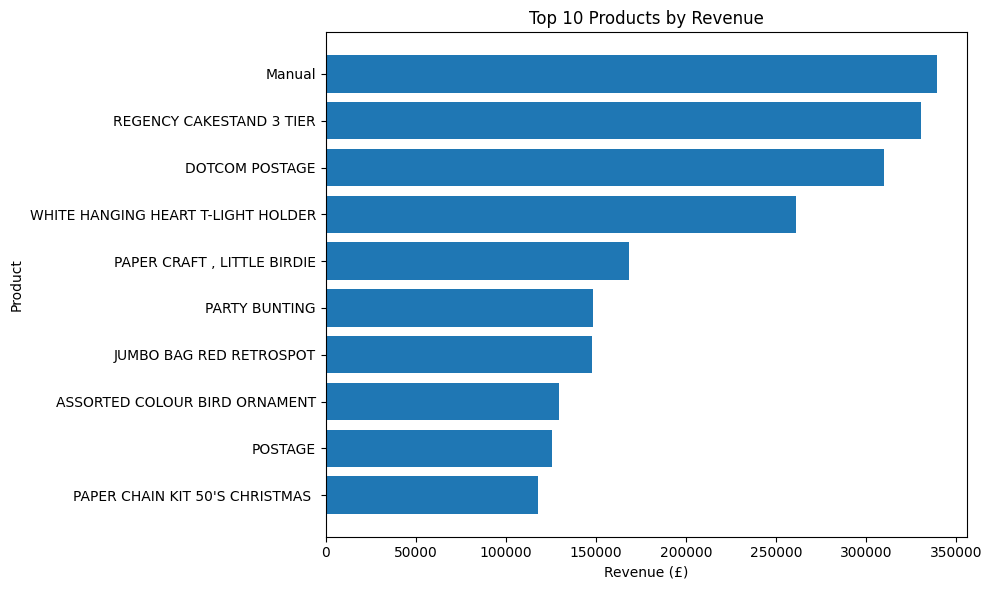

In [175]:
# TOP PRODUCTS VISUALIZATION


plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"],
    top_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [176]:
# TOP COUNTRIES BY REVENUE
country_revenue = (
    clean_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(country_revenue)

,Country,Revenue
0,United Kingdom,1.741022e+07
1,EIRE,6.587673e+05
2,Netherlands,5.540381e+05
3,Germany,4.250197e+05
4,France,3.504561e+05
5,Australia,1.692835e+05
6,Spain,1.083325e+05
7,Switzerland,1.006856e+05
8,Sweden,9.186982e+04
9,Denmark,6.858069e+04


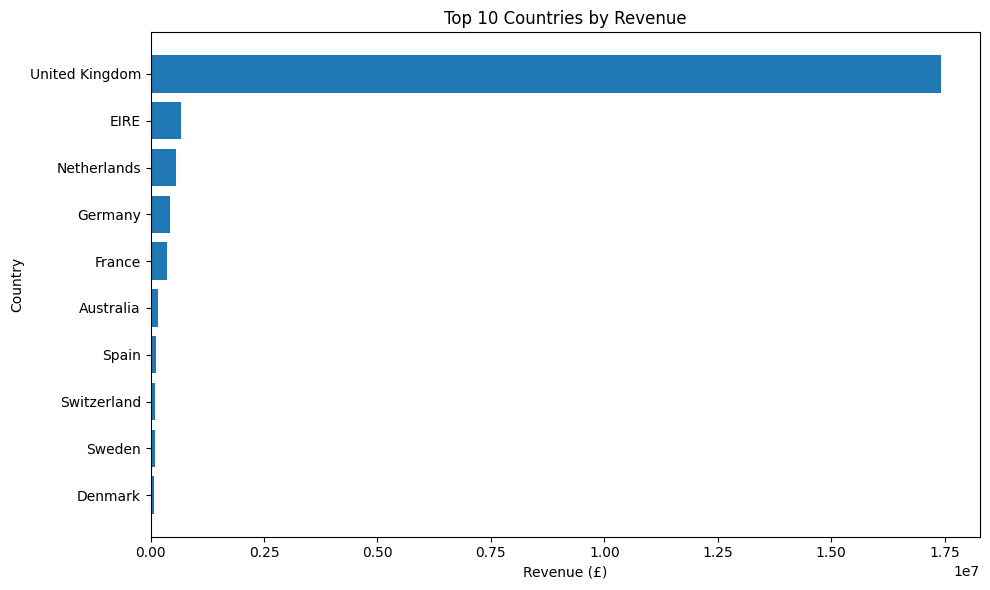

In [177]:
# COUNTRY REVENUE VISUALIZATION

plt.figure(figsize=(10, 6))

plt.barh(
    country_revenue["Country"],
    country_revenue["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [178]:
# TOP CUSTOMERS BY REVENUE

top_customers = (
    clean_df
    .dropna(subset=["Customer ID"])
    .groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_customers)

,Customer ID,Revenue
0,18102.0,580987.04
1,14646.0,528602.52
2,14156.0,313437.62
3,14911.0,291420.81
4,17450.0,244784.25
5,13694.0,195640.69
6,17511.0,172132.87
7,16446.0,168472.50
8,16684.0,147142.77
9,12415.0,144458.37


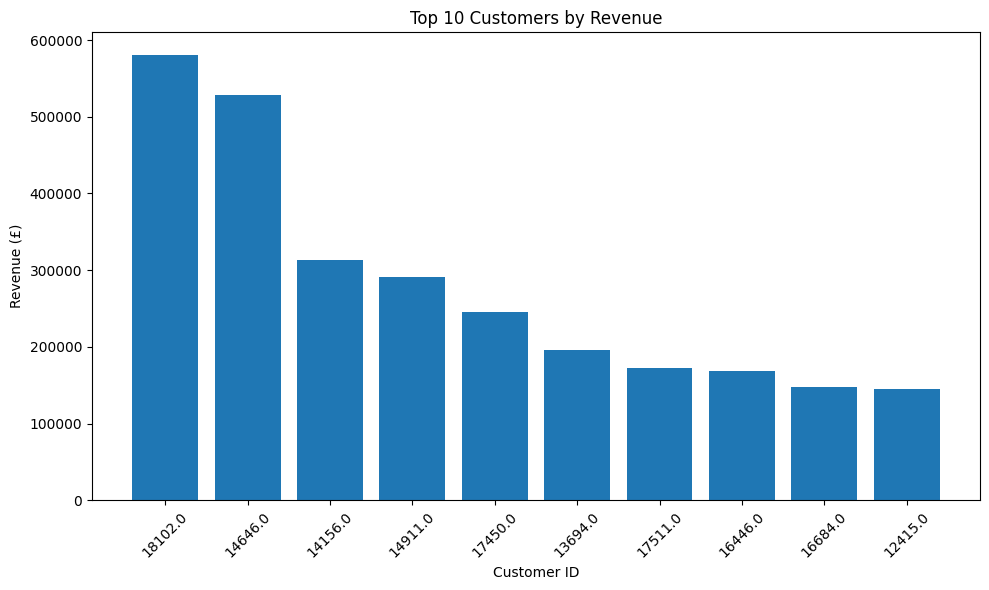

In [179]:
# TOP CUSTOMER VISUALIZATION

plt.figure(figsize=(10, 6))

plt.bar(
    top_customers["Customer ID"].astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [180]:
# NUMPY REVENUE ANALYSIS

# Convert Revenue column into a NumPy array
revenue_array = clean_df["Revenue"].to_numpy()

# Calculate statistics using NumPy
numpy_mean = np.mean(revenue_array)
numpy_median = np.median(revenue_array)
numpy_std = np.std(revenue_array)

print(f"Mean Transaction Revenue: £{numpy_mean:.2f}")
print(f"Median Transaction Revenue: £{numpy_median:.2f}")
print(f"Revenue Standard Deviation: £{numpy_std:.2f}")

Mean Transaction Revenue: £20.32
Median Transaction Revenue: £10.08
Revenue Standard Deviation: £205.72


In [181]:
# QUANTITY VS REVENUE CORRELATION

# Calculate correlation between quantity sold
# and revenue.

correlation = clean_df[
    ["Quantity", "Revenue"]
].corr()

display(correlation)

,Quantity,Revenue
Quantity,1.00000,0.80692
Revenue,0.80692,1.00000


In [182]:
# FINAL BUSINESS SUMMARY

print("==========================================")
print("       ONLINE RETAIL BUSINESS ANALYSIS")
print("==========================================")

print(f"\nTotal Revenue: £{total_revenue:,.2f}")

print(f"Total Products Sold: {total_quantity:,}")

print(f"Total Transactions: {total_transactions:,}")

print(f"Unique Products: {total_products:,}")

print(f"Unique Customers: {total_customers:,}")

print(f"Countries Served: {total_countries}")

print(f"Average Order Value: £{average_order_value:,.2f}")

print("\nTop Product:")
print(top_products.iloc[0]["Description"])

print("\nTop Country:")
print(country_revenue.iloc[0]["Country"])

print("\nTop Customer:")
print(top_customers.iloc[0]["Customer ID"])

print("\n==========================================")

       ONLINE RETAIL BUSINESS ANALYSIS

Total Revenue: £20,476,282.45
Total Products Sold: 11,205,156
Total Transactions: 40,077
Unique Products: 4,918
Unique Customers: 5,878
Countries Served: 43
Average Order Value: £510.92

Top Product:
Manual

Top Country:
United Kingdom

Top Customer:
18102.0



# Final Business Insights

## Key Findings

### 1. Overall Business Performance
The analysis calculated total revenue, total quantity sold, total transactions,
unique products, unique customers, and average order value.

### 2. Monthly Sales Performance
Monthly revenue analysis helps identify periods of higher and lower sales activity
and provides an overview of the business sales trend over time.

### 3. Product Performance
The top 10 products by revenue identify the products that contribute most to
overall business revenue.

### 4. Geographic Performance
Country-level revenue analysis identifies the strongest markets and shows where
the business generates the majority of its revenue.

### 5. Customer Performance
Customer-level analysis identifies high-value customers based on their total
revenue contribution.

### 6. Revenue and Quantity Relationship
Correlation analysis helps understand the relationship between the quantity of
products sold and transaction revenue.

## Conclusion

This project demonstrates how Python can be used to transform a large,
real-world retail dataset into meaningful business insights.

The analysis covered data cleaning, missing-value handling, duplicate removal,
feature engineering, statistical analysis, customer analysis, product analysis,
geographic analysis, and data visualization using Pandas, NumPy, and Matplotlib.

In [183]:
# FINAL PROJECT CHECK
print("PROJECT STATUS")
print("============================")

print("Dataset:", clean_df.shape)
print("Duplicates:", clean_df.duplicated().sum())
print("Missing Revenue:", clean_df["Revenue"].isnull().sum())
print("Missing Dates:", clean_df["InvoiceDate"].isnull().sum())

print("\nLibraries Used:")
print("✓ Pandas")
print("✓ NumPy")
print("✓ Matplotlib")

print("\nAnalysis Completed:")
print("✓ Data Cleaning")
print("✓ Missing Value Analysis")
print("✓ Revenue Analysis")
print("✓ Monthly Trend Analysis")
print("✓ Product Analysis")
print("✓ Country Analysis")
print("✓ Customer Analysis")
print("✓ Statistical Analysis")

print("\nPROJECT READY FOR SUBMISSION")

PROJECT STATUS
Dataset: (1007914, 14)
Duplicates: 0
Missing Revenue: 0
Missing Dates: 0

Libraries Used:
✓ Pandas
✓ NumPy
✓ Matplotlib

Analysis Completed:
✓ Data Cleaning
✓ Missing Value Analysis
✓ Revenue Analysis
✓ Monthly Trend Analysis
✓ Product Analysis
✓ Country Analysis
✓ Customer Analysis
✓ Statistical Analysis

PROJECT READY FOR SUBMISSION


# Conclusion

This project analyzed a real-world Online Retail dataset using Python.

The dataset was cleaned by handling missing values, removing cancelled
transactions and duplicate records, validating quantities and prices, and
creating useful features such as Revenue, Year, Month, Day, and Hour.

Using Pandas and NumPy, the analysis explored:

- Overall business performance
- Monthly revenue trends
- Top-performing products
- Revenue by country
- High-value customers
- Transaction-level statistics
- Relationship between quantity and revenue

Matplotlib was used to visualize important business trends.

Overall, this project demonstrates the complete data analysis workflow:

**Raw Data → Cleaning → Feature Engineering → Analysis → Visualization → Insights**

The analysis shows how Python can transform a large real-world dataset into
meaningful information that can support business decisions.